# Duration, Logical Duration, and Performed Duration

**CAMAT workflow 2 of 3: parse music into CAMAT representations.** See [Getting started](../docs/getting-started.md#choose-a-workflow) for the three workflows and `docs/guides/parsing-representations.md` for the representation contract.

This offline tutorial uses CAMAT's default Verovio parser and a small MEI score bundled with the package. It therefore works outside the source repository after installing a CAMAT release that includes the duration-semantics schema. It keeps three concepts separate:

- **`Duration`**: metric duration of one encoded note segment, measured in quarter-note units. Dots and tuplet ratios are already included. Grace notes normally have zero metric duration.
- **`Logical Duration`**: duration of one logical note. For a tie chain, this is the sum of its segment durations and is stored once on the chain head.
- **`Performed Duration`**: optional measured or model-generated sounding duration. The parser leaves it nullable because notation metadata alone does not define a unique performance.

Fermatas, articulations, ornaments, slurs, tuple membership, and technical instructions remain metadata. Do not multiply `Duration` by those fields unless you explicitly run a separate performance-realization model.

In [1]:
from contextlib import ExitStack
from importlib.resources import as_file, files
from pathlib import Path
import sys

import numpy as np
import pandas as pd
from IPython.display import display

# This notebook lives in notebooks/, so cwd is not the repo root.
_here = Path.cwd().resolve()
_root = next(
    (p for p in (_here, *_here.parents) if (p / "camat" / "__init__.py").is_file()),
    None,
)
if _root is not None and str(_root) not in sys.path:
    sys.path.insert(0, str(_root))

from camat import __version__, build_duration_counts

try:
    from camat import parse_files
except ImportError as exc:
    raise RuntimeError(
        f'CAMAT {__version__} predates this notebook. Install a release whose '
        'changelog includes the duration-semantics feature, or install the current '
        'source checkout.'
    ) from exc

_RESOURCE_STACK = ExitStack()
_packaged_source = files('camat').joinpath('examples', 'duration_semantics.mei')
SOURCE = _RESOURCE_STACK.enter_context(as_file(_packaged_source))

print('CAMAT:', __version__)
print('Source:', SOURCE)

CAMAT: 0.2.1b1
Source: /home/egor/Nextcloud/code/public_repos/camat_v2/camat/examples/duration_semantics.mei


## Small Verovio score preview

Render the same packaged MEI example used by the duration checks. For a remote score, replace `vrv_load_from_file(str(SOURCE))` with `vrv_load_from_url(url)`.

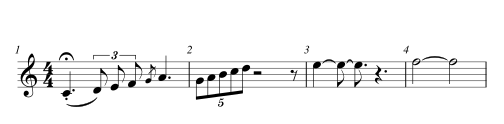

In [2]:
from camat import (
    vrv_display_svg,
    vrv_load_from_file,
    vrv_quiet,
    vrv_render_all_pages,
    vrv_set_options,
)

with vrv_quiet():
    vrv_set_options(
        pageWidth=9000,
        pageHeight=1200,
        scale=35,
        breaks='none',
        mnumInterval=1,
    )
    _ = vrv_load_from_file(str(SOURCE))
    for svg in vrv_render_all_pages():
        vrv_display_svg(svg)

## Parse both segment and logical-note views

Use `collapse_tied_pitch_events=False` whenever every encoded segment must remain a row. Use `True` when one row per logical tied note is more useful. Zero-duration filtering and rounding are disabled here so the checks use exact parser values and retain grace notes.

In [3]:
def parse_pitch_view(*, collapse_ties):
    results, _, _ = parse_files(
        [str(SOURCE)],
        parsing_backend='verovio',
        backend='none',
        display_preview_df_pitch=False,
        display_preview_df_events=False,
        print_parsed_summary=False,
        show_progress=False,
        quiet_native_warnings=True,
        filter_zero_duration=False,
        adjust_fractional_duration=False,
        parse_enharmonic=True,
        include_xml_ids=True,
        collapse_tied_pitch_events=collapse_ties,
        n_jobs=1,
    )
    return results[0]['df_pitch']

df_segments = parse_pitch_view(collapse_ties=False)
df_logical = parse_pitch_view(collapse_ties=True)

required_duration_columns = {'Duration', 'Logical Duration', 'Performed Duration'}
missing_duration_columns = required_duration_columns.difference(df_segments.columns)
if missing_duration_columns:
    raise RuntimeError(
        f'CAMAT {__version__} predates this notebook schema; missing columns: '
        f'{sorted(missing_duration_columns)}. Install a release whose changelog '
        'includes the duration-semantics feature, or install the current source checkout.'
    )

print(f'encoded segment rows: {len(df_segments)}')
print(f'collapsed logical rows: {len(df_logical)}')
display(df_segments.head())

Processing (verovio): duration_semantics.mei -> 00_duration_semantics
Extracted non-barline MEI events: 9 event(s), types=['bend', 'measure', 'slur', 'tie', 'tuplet_span'].
Processing (verovio): duration_semantics.mei -> 00_duration_semantics
Extracted non-barline MEI events: 9 event(s), types=['bend', 'measure', 'slur', 'tie', 'tuplet_span'].
encoded segment rows: 16
collapsed logical rows: 13


,Measure,Local Onset,Global Onset,Duration,Pitch,Pitch Enharmonic,MIDI,Voice,xml_id,grace,tied,slurred,tuplet,fermata,articulations,ornaments,technical,Logical Duration,Performed Duration
0,1,0.000000,0.000000,1.500000,C4,C4,60,P1 - Voice 1,dotted,<NA>,NaN,start,NaN,True,stacc,trill,bend,1.500000,<NA>
1,1,1.500000,1.500000,0.333333,D4,D4,62,P1 - Voice 1,triplet-1,<NA>,NaN,stop,member,<NA>,NaN,NaN,NaN,0.333333,<NA>
2,1,1.833333,1.833333,0.333333,E4,E4,64,P1 - Voice 1,triplet-2,<NA>,NaN,NaN,member,<NA>,NaN,NaN,NaN,0.333333,<NA>
3,1,2.166667,2.166667,0.333333,F4,F4,65,P1 - Voice 1,triplet-3,<NA>,NaN,NaN,member,<NA>,NaN,NaN,NaN,0.333333,<NA>
4,1,2.500000,2.500000,0.000000,G4,G4,67,P1 - Voice 1,grace,True,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,0.000000,<NA>


## 1. Metric segment duration

The fixture contains a dotted quarter, a nested triplet, a `tupletSpan` quintuplet, and a grace note. `Duration` already contains the dot and tuplet effects exactly once.

In [4]:
metric_ids = [
    'dotted',
    'triplet-1', 'triplet-2', 'triplet-3',
    'quintuplet-1', 'quintuplet-2', 'quintuplet-3',
    'quintuplet-4', 'quintuplet-5',
    'grace',
]
metric_examples = (
    df_segments.set_index('xml_id')
    .loc[metric_ids, [
        'Measure', 'Global Onset', 'Duration', 'Logical Duration',
        'grace', 'tuplet',
    ]]
)
display(metric_examples)

assert metric_examples.at['dotted', 'Duration'] == 1.5
assert np.allclose(
    metric_examples.loc[['triplet-1', 'triplet-2', 'triplet-3'], 'Duration'],
    [1 / 3] * 3,
)
assert np.allclose(
    metric_examples.loc[[f'quintuplet-{i}' for i in range(1, 6)], 'Duration'],
    [0.3] * 5,
)
assert metric_examples.at['grace', 'Duration'] == 0.0

,Measure,Global Onset,Duration,Logical Duration,grace,tuplet
xml_id,,,,,,
dotted,1,0.000000,1.500000,1.500000,<NA>,NaN
triplet-1,1,1.500000,0.333333,0.333333,<NA>,member
triplet-2,1,1.833333,0.333333,0.333333,<NA>,member
triplet-3,1,2.166667,0.333333,0.333333,<NA>,member
quintuplet-1,2,4.000000,0.300000,0.300000,<NA>,start
quintuplet-2,2,4.300000,0.300000,0.300000,<NA>,member
quintuplet-3,2,4.600000,0.300000,0.300000,<NA>,member
quintuplet-4,2,4.900000,0.300000,0.300000,<NA>,member
quintuplet-5,2,5.200000,0.300000,0.300000,<NA>,stop


## 2. Logical tied duration

In the uncollapsed view, every segment keeps its own `Duration`. `Logical Duration` is stored only on the chain head, so aggregating that column does not count the same logical note more than once. In the collapsed view, continuation rows disappear, while the head's metric `Duration` remains unchanged.

In [5]:
tie_ids = ['tie-a', 'tie-b', 'tie-c']
tie_columns = [
    'xml_id', 'Global Onset', 'Duration', 'Logical Duration',
    'Performed Duration', 'tied',
]

uncollapsed_tie = df_segments[df_segments['xml_id'].isin(tie_ids)][tie_columns]
collapsed_tie = df_logical[df_logical['xml_id'].isin(tie_ids)][tie_columns]

print('Uncollapsed segments')
display(uncollapsed_tie)
print('Collapsed logical note')
display(collapsed_tie)

segment_sum = uncollapsed_tie['Duration'].sum()
assert segment_sum == 2.25
assert collapsed_tie.iloc[0]['Duration'] == 1.0
assert collapsed_tie.iloc[0]['Logical Duration'] == segment_sum
assert df_segments['Logical Duration'].sum() == df_logical['Logical Duration'].sum()

Uncollapsed segments


,xml_id,Global Onset,Duration,Logical Duration,Performed Duration,tied
11,tie-a,8.0,1.00,2.25,<NA>,start
12,tie-b,9.0,0.50,NaN,<NA>,both
13,tie-c,9.5,0.75,NaN,<NA>,stop


Collapsed logical note


,xml_id,Global Onset,Duration,Logical Duration,Performed Duration,tied
11,tie-a,8.0,1.0,2.25,<NA>,start


## 3. Expressive and technical notation remains metadata

The decorated dotted note demonstrates that fermatas, articulations, ornaments, slurs, and technical instructions are represented alongside duration rather than folded into it.

In [6]:
metadata_columns = [
    'xml_id', 'Duration', 'Logical Duration', 'Performed Duration',
    'grace', 'tied', 'slurred', 'tuplet', 'fermata',
    'articulations', 'ornaments', 'technical',
]
decorated = df_segments.loc[df_segments['xml_id'] == 'dotted', metadata_columns]
display(decorated)

assert decorated.iloc[0]['Duration'] == 1.5
assert pd.isna(decorated.iloc[0]['Performed Duration'])

,xml_id,Duration,Logical Duration,Performed Duration,grace,tied,slurred,tuplet,fermata,articulations,ornaments,technical
0,dotted,1.5,1.5,<NA>,<NA>,NaN,start,NaN,True,stacc,trill,bend


## 4. Attach optional performed duration explicitly

The parser intentionally leaves `Performed Duration` empty. The example below attaches external observations by `xml_id`; it does not infer timing from fermatas or articulations. Keep the unit documented. Here the illustrative observations are expressed in quarter-note units. If your measurements are seconds, prefer a clearly named column such as `Performed Duration Seconds`.

In [7]:
def attach_performed_durations(df, performed_by_xml_id, *, unit='quarter-note units'):
    result = df.copy()
    result['Performed Duration'] = pd.to_numeric(
        result['xml_id'].map(performed_by_xml_id),
        errors='coerce',
    ).astype('Float64')
    result.attrs['performed_duration_unit'] = unit
    return result

# Replace these illustrative values with measurements or model output.
performed_by_xml_id = {
    'dotted': 1.62,
    'tie-a': 2.31,
    'attr-tie-a': 4.08,
}
df_performed = attach_performed_durations(df_logical, performed_by_xml_id)

print('Performed-duration unit:', df_performed.attrs['performed_duration_unit'])
display(
    df_performed.loc[
        df_performed['Performed Duration'].notna(),
        ['xml_id', 'Duration', 'Logical Duration', 'Performed Duration',
         'fermata', 'articulations'],
    ]
)

Performed-duration unit: quarter-note units


,xml_id,Duration,Logical Duration,Performed Duration,fermata,articulations
0,dotted,1.5,1.50,1.62,True,stacc
11,tie-a,1.0,2.25,2.31,<NA>,NaN
12,attr-tie-a,2.0,4.00,4.08,<NA>,NaN


## 5. Analyze one duration concept at a time

Pass `duration_column` explicitly. Segment distributions require the uncollapsed table; logical-note distributions use the logical column, where tie-chain totals occur once. Performed-duration distributions should use only rows populated by the chosen performance dataset or model.

In [8]:
metric_counts, _ = build_duration_counts(
    df_segments,
    drop_zero=False,
    round_decimals=6,
    duration_column='Duration',
)
logical_counts, _ = build_duration_counts(
    df_logical,
    drop_zero=False,
    round_decimals=6,
    duration_column='Logical Duration',
)
performed_counts, _ = build_duration_counts(
    df_performed,
    drop_zero=False,
    round_decimals=6,
    duration_column='Performed Duration',
)

print('Metric segment distribution')
display(metric_counts)
print('Logical-note distribution')
display(logical_counts)
print('Observed/modelled performed-duration distribution')
display(performed_counts)

Metric segment distribution


,Duration,count
0,0.000000,1
1,0.300000,5
2,0.333333,3
3,0.500000,1
4,0.750000,1
5,1.000000,1
6,1.500000,2
7,2.000000,2


Logical-note distribution


,Logical Duration,count
0,0.000000,1
1,0.300000,5
2,0.333333,3
3,1.500000,2
4,2.250000,1
5,4.000000,1


Observed/modelled performed-duration distribution


,Performed Duration,count
0,1.62,1
1,2.31,1
2,4.08,1


In [9]:
display(df_logical)

,Measure,Local Onset,Global Onset,Duration,Pitch,Pitch Enharmonic,MIDI,Voice,xml_id,grace,tied,slurred,tuplet,fermata,articulations,ornaments,technical,Logical Duration,Performed Duration
0,1,0.000000,0.000000,1.500000,C4,C4,60,P1 - Voice 1,dotted,<NA>,NaN,start,NaN,True,stacc,trill,bend,1.500000,<NA>
1,1,1.500000,1.500000,0.333333,D4,D4,62,P1 - Voice 1,triplet-1,<NA>,NaN,stop,member,<NA>,NaN,NaN,NaN,0.333333,<NA>
2,1,1.833333,1.833333,0.333333,E4,E4,64,P1 - Voice 1,triplet-2,<NA>,NaN,NaN,member,<NA>,NaN,NaN,NaN,0.333333,<NA>
3,1,2.166667,2.166667,0.333333,F4,F4,65,P1 - Voice 1,triplet-3,<NA>,NaN,NaN,member,<NA>,NaN,NaN,NaN,0.333333,<NA>
4,1,2.500000,2.500000,0.000000,G4,G4,67,P1 - Voice 1,grace,True,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,0.000000,<NA>
5,1,2.500000,2.500000,1.500000,A4,A4,69,P1 - Voice 1,measure-1-tail,<NA>,NaN,NaN,NaN,<NA>,NaN,NaN,NaN,1.500000,<NA>
6,2,0.000000,4.000000,0.300000,G4,G4,67,P1 - Voice 1,quintuplet-1,<NA>,NaN,NaN,start,<NA>,NaN,NaN,NaN,0.300000,<NA>
7,2,0.300000,4.300000,0.300000,A4,A4,69,P1 - Voice 1,quintuplet-2,<NA>,NaN,NaN,member,<NA>,NaN,NaN,NaN,0.300000,<NA>
8,2,0.600000,4.600000,0.300000,B4,B4,71,P1 - Voice 1,quintuplet-3,<NA>,NaN,NaN,member,<NA>,NaN,NaN,NaN,0.300000,<NA>
9,2,0.900000,4.900000,0.300000,C5,C5,72,P1 - Voice 1,quintuplet-4,<NA>,NaN,NaN,member,<NA>,NaN,NaN,NaN,0.300000,<NA>


## Practical rules

1. Use uncollapsed `Duration` rows for encoded-segment analysis.
2. Use `Logical Duration` for note-level analysis across ties. Continuation rows are nullable in the uncollapsed view and absent in the collapsed view.
3. Do not reapply dots or tuplet ratios.
4. Do not convert fermatas, articulations, ornaments, slurs, or technical instructions into timing unless a separate documented model does so.
5. Keep performed-duration units and provenance explicit.